# RNN(Recurrent Neural Network) 実践的学習教材

このノートブックでは、系列データを扱う基本モデルであるRNNを、数式・フルスクラッチ実装・学習実験の順に理解します。自然言語や時系列センサーデータの前に、まずは外部データに依存しない合成タスクで「RNNが何を記憶し、どこで苦手になるか」を観察します。

扱う内容:

- RNNの状態更新式と系列分類の考え方
- PyTorchによるVanilla RNNセルのフルスクラッチ実装
- 遅延コピー分類タスクによる短期記憶の学習
- LSTM / GRUとの実践的な比較
- 勾配消失・勾配爆発とgradient clipping
- 可変長系列を扱うためのpadding / packing
- RNNとSSM(State Space Model)の違い
- 発展課題と実務での使い分け

小さな合成データを使うため、GPUは必須ではありません。

## 0. 依存関係

実装では `numpy`, `matplotlib`, `torch` を使います。PyTorchが未導入の場合は、環境に合う方法でインストールしてください。

```bash
pip install torch numpy matplotlib
```

この教材はCPUでも動くように、データサイズとエポック数を小さめにしています。

In [1]:
import math
import random
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
except ModuleNotFoundError as e:
    raise ModuleNotFoundError(
        "PyTorchが見つかりません。`pip install torch` を実行するか、PyTorch入りの環境で開いてください。"
    ) from e


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## 1. RNNの基本式

系列入力を $x_1, x_2, \dots, x_T$ とします。RNNは時刻 $t$ ごとに隠れ状態 $h_t$ を更新します。

$$
h_t = \tanh(W_{xh}x_t + W_{hh}h_{t-1} + b_h)
$$

系列全体を分類する場合は、最後の隠れ状態 $h_T$ を使って予測します。

$$
\hat{y} = \operatorname{softmax}(W_{hy}h_T + b_y)
$$

RNNの直感は「同じ小さなニューラルネットワークを時刻方向に繰り返し適用する」ことです。重み $W_{xh}, W_{hh}$ は全時刻で共有されるため、系列長が変わっても同じモデルを使えます。

## 2. 合成タスク: 遅延コピー分類

まず、RNNが系列の情報を保持できるかを試します。入力系列は0/1のビット列で、正解ラベルは「先頭から `delay` 番目のビット」です。モデルは最後まで系列を読んだあと、指定された1ビットを答えます。

例: `delay=0` なら先頭ビット、`delay=3` なら4番目のビットを最後に分類します。最初の実験では学習の成功を確認しやすいように、最後のビットを答える簡単な設定から始めます。

このタスクは単純ですが、答えるべきビットが系列の前の方にあるほど、必要な情報を隠れ状態に長く保持する必要があります。

In [2]:
@dataclass
class CopyTaskConfig:
    seq_len: int = 30
    delay: int = 0
    n_train: int = 2048
    n_test: int = 512
    batch_size: int = 64


def make_delayed_copy_data(n_samples: int, seq_len: int, delay: int):
    x_bits = torch.randint(0, 2, (n_samples, seq_len))
    y = x_bits[:, delay].long()
    x = F.one_hot(x_bits, num_classes=2).float()
    return x, y


def make_loader(x, y, batch_size=64, shuffle=True):
    dataset = torch.utils.data.TensorDataset(x, y)
    return torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


cfg = CopyTaskConfig(seq_len=30, delay=29)
x_train, y_train = make_delayed_copy_data(cfg.n_train, cfg.seq_len, cfg.delay)
x_test, y_test = make_delayed_copy_data(cfg.n_test, cfg.seq_len, cfg.delay)

print("x_train:", x_train.shape)  # (batch, time, input_dim)
print("y_train:", y_train.shape)
print("first sequence bits:", x_train[0].argmax(dim=-1).tolist())
print("label:", int(y_train[0]))

x_train: torch.Size([2048, 30, 2])
y_train: torch.Size([2048])
first sequence bits: [0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1]
label: 1


## 3. Vanilla RNNをフルスクラッチ実装する

PyTorchには `nn.RNN` がありますが、まずはRNNセルを自分で書きます。入力テンソルは `(batch, time, input_dim)` とし、時刻方向にforループで状態を更新します。

実務では組み込み層を使うことが多いですが、セルを自作すると「どこで状態が流れているか」「どこで勾配が長く伝播するか」が見えます。

In [3]:
class VanillaRNNClassifier(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, num_classes: int):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.x_to_h = nn.Linear(input_dim, hidden_dim)
        self.h_to_h = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.head = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, return_states=False):
        batch_size, seq_len, _ = x.shape
        h = x.new_zeros(batch_size, self.hidden_dim)
        states = []
        for t in range(seq_len):
            h = torch.tanh(self.x_to_h(x[:, t]) + self.h_to_h(h))
            if return_states:
                states.append(h)
        logits = self.head(h)
        if return_states:
            return logits, torch.stack(states, dim=1)
        return logits


model = VanillaRNNClassifier(input_dim=2, hidden_dim=32, num_classes=2).to(device)
sample_logits, sample_states = model(x_train[:4].to(device), return_states=True)
print("logits:", sample_logits.shape)
print("states:", sample_states.shape)

logits: torch.Size([4, 2])
states: torch.Size([4, 30, 32])


## 4. 学習ループ

系列分類でも、損失関数と最適化の基本は通常の分類と同じです。ここでは最後の時刻の出力だけを使って `cross_entropy` を計算します。

RNNでは勾配爆発が起きることがあるため、`clip_grad_norm_` で勾配ノルムを制限します。これはRNN系モデルでよく使う実践的な安定化手法です。

In [21]:
from tqdm import tqdm

def accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb).argmax(dim=-1)
            correct += (pred == yb).sum().item()
            total += yb.numel()
    return correct / total


def train_classifier(model, train_loader, test_loader, epochs=8, lr=1e-3, clip=1.0):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"loss": [], "train_acc": [], "test_acc": [], "grad_norm": []}

    for epoch in tqdm(range(1, epochs + 1), desc="Epoch: "):
        model.train()
        total_loss = 0.0
        total_grad_norm = 0.0
        steps = 0
        for xb, yb in tqdm(train_loader, desc=f"Batch: "):
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad(set_to_none=True)
            loss = F.cross_entropy(model(xb), yb)
            loss.backward()
            grad_norm = nn.utils.clip_grad_norm_(model.parameters(), clip)
            optimizer.step()

            total_loss += loss.item()
            total_grad_norm += float(grad_norm)
            steps += 1

        history["loss"].append(total_loss / steps)
        history["grad_norm"].append(total_grad_norm / steps)
        history["train_acc"].append(accuracy(model, train_loader))
        history["test_acc"].append(accuracy(model, test_loader))
        print(
            f"epoch {epoch:02d} | loss {history['loss'][-1]:.4f} | "
            f"train {history['train_acc'][-1]:.3f} | test {history['test_acc'][-1]:.3f} | "
            f"grad {history['grad_norm'][-1]:.2f}"
        )
    return history

In [5]:
set_seed(42)
train_loader = make_loader(x_train, y_train, cfg.batch_size, shuffle=True)
test_loader = make_loader(x_test, y_test, cfg.batch_size, shuffle=False)

vanilla = VanillaRNNClassifier(input_dim=2, hidden_dim=32, num_classes=2)
vanilla_history = train_classifier(vanilla, train_loader, test_loader, epochs=8, lr=1e-3)

epoch 01 | loss 0.4905 | train 1.000 | test 1.000 | grad 0.81
epoch 02 | loss 0.2957 | train 1.000 | test 1.000 | grad 0.58
epoch 03 | loss 0.1803 | train 1.000 | test 1.000 | grad 0.41
epoch 04 | loss 0.1133 | train 1.000 | test 1.000 | grad 0.29
epoch 05 | loss 0.0746 | train 1.000 | test 1.000 | grad 0.21
epoch 06 | loss 0.0516 | train 1.000 | test 1.000 | grad 0.15
epoch 07 | loss 0.0375 | train 1.000 | test 1.000 | grad 0.12
epoch 08 | loss 0.0283 | train 1.000 | test 1.000 | grad 0.09


## 5. 学習曲線を見る

損失だけでなく、汎化性能としてtest accuracyも確認します。合成タスクでも、学習曲線を見る習慣は重要です。

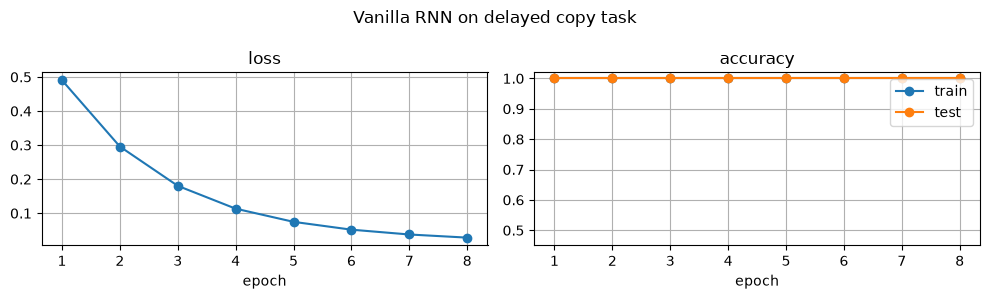

In [6]:
def plot_history(history, title="training curve"):
    epochs = np.arange(1, len(history["loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    axes[0].plot(epochs, history["loss"], marker="o")
    axes[0].set_title("loss")
    axes[0].set_xlabel("epoch")
    axes[0].grid(True)

    axes[1].plot(epochs, history["train_acc"], marker="o", label="train")
    axes[1].plot(epochs, history["test_acc"], marker="o", label="test")
    axes[1].set_title("accuracy")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylim(0.45, 1.02)
    axes[1].grid(True)
    axes[1].legend()
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


plot_history(vanilla_history, "Vanilla RNN on delayed copy task")

## 6. 隠れ状態を観察する

RNNは各時刻で隠れ状態を更新します。次の可視化では、1つの入力系列に対して、隠れ状態の一部の次元が時刻とともにどう変わるかを見ます。

完全に解釈可能な特徴になるとは限りませんが、系列全体を固定長ベクトルへ圧縮している様子を確認できます。

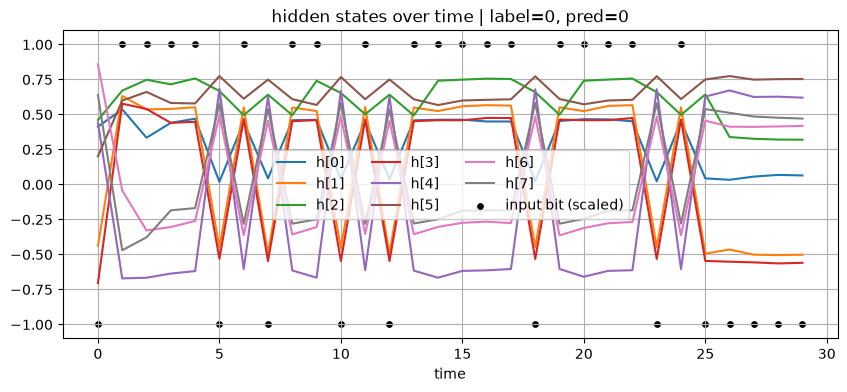

In [7]:
vanilla.eval()
with torch.no_grad():
    logits, states = vanilla(x_test[:1].to(device), return_states=True)
    pred = logits.argmax(dim=-1).item()

bits = x_test[0].argmax(dim=-1).numpy()
states_np = states[0, :, :8].cpu().numpy()

plt.figure(figsize=(10, 4))
for i in range(states_np.shape[1]):
    plt.plot(states_np[:, i], label=f"h[{i}]")
plt.scatter(np.arange(len(bits)), bits * 2 - 1, c="black", s=15, label="input bit (scaled)")
plt.title(f"hidden states over time | label={int(y_test[0])}, pred={pred}")
plt.xlabel("time")
plt.grid(True)
plt.legend(ncol=3)
plt.show()

## 7. 長期依存で難しくなることを確認する

今度は系列長を長くし、先頭ビットを最後に答える設定を試します。必要な情報が長いステップをまたいで伝わるため、Vanilla RNNでは学習が不安定になりやすくなります。

epoch 01 | loss 0.7113 | train 0.510 | test 0.488 | grad 0.39
epoch 02 | loss 0.6940 | train 0.521 | test 0.508 | grad 0.24
epoch 03 | loss 0.6937 | train 0.513 | test 0.523 | grad 0.28
epoch 04 | loss 0.6930 | train 0.521 | test 0.506 | grad 0.25
epoch 05 | loss 0.6927 | train 0.516 | test 0.520 | grad 0.29
epoch 06 | loss 0.6935 | train 0.517 | test 0.525 | grad 0.28


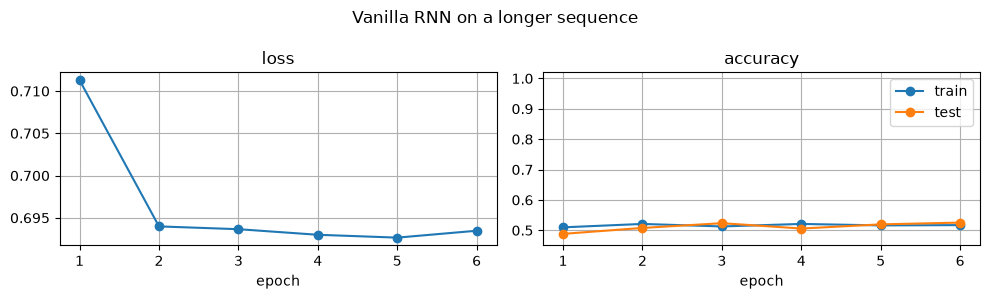

In [8]:
def run_copy_experiment(model_factory, seq_len, delay=0, epochs=6, hidden_dim=32):
    set_seed(123)
    x_tr, y_tr = make_delayed_copy_data(2048, seq_len, delay)
    x_te, y_te = make_delayed_copy_data(512, seq_len, delay)
    tr_loader = make_loader(x_tr, y_tr, 64, shuffle=True)
    te_loader = make_loader(x_te, y_te, 64, shuffle=False)
    model = model_factory(hidden_dim)
    hist = train_classifier(model, tr_loader, te_loader, epochs=epochs, lr=1e-3)
    return model, hist


long_rnn, long_rnn_history = run_copy_experiment(
    lambda h: VanillaRNNClassifier(input_dim=2, hidden_dim=h, num_classes=2),
    seq_len=80,
    delay=0,
    epochs=6,
)
plot_history(long_rnn_history, "Vanilla RNN on a longer sequence")

## 8. LSTM / GRUと比較する

Vanilla RNNの弱点を補うために、LSTMやGRUではゲート機構を使います。ゲートは、各時刻で「新しい入力をどれだけ取り込むか」「過去の状態をどれだけ残すか」「出力にどれだけ見せるか」を0から1の重みとして学習する仕組みです。

### LSTMの考え方

LSTM(Long Short-Term Memory)は、通常の隠れ状態 $h_t$ に加えて、セル状態 $c_t$ を持ちます。セル状態は「長期記憶」に近い役割を持ち、忘却ゲート・入力ゲート・出力ゲートによって更新されます。

$$
f_t = \sigma(W_f[x_t, h_{t-1}] + b_f)
$$

$$
i_t = \sigma(W_i[x_t, h_{t-1}] + b_i), \quad \tilde{c}_t = \tanh(W_c[x_t, h_{t-1}] + b_c)
$$

$$
c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t
$$

$$
o_t = \sigma(W_o[x_t, h_{t-1}] + b_o), \quad h_t = o_t \odot \tanh(c_t)
$$

`f_t` は過去の記憶を残す割合、`i_t` は新しい候補記憶を取り込む割合、`o_t` はセル状態を出力に見せる割合です。Vanilla RNNでは毎時刻で状態全体を上書きしやすいのに対し、LSTMはセル状態を比較的まっすぐ流せるため、長めの依存関係を保持しやすくなります。

### GRUの考え方

GRU(Gated Recurrent Unit)は、LSTMを少し簡略化したゲート付きRNNです。セル状態 $c_t$ を分けず、隠れ状態 $h_t$ だけで記憶を表します。代表的には、更新ゲート $z_t$ とリセットゲート $r_t$ を使います。

$$
z_t = \sigma(W_z[x_t, h_{t-1}] + b_z), \quad r_t = \sigma(W_r[x_t, h_{t-1}] + b_r)
$$

$$
\tilde{h}_t = \tanh(W_h[x_t, r_t \odot h_{t-1}] + b_h)
$$

$$
h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t
$$

`z_t` は古い状態と新しい候補状態の混ぜ具合を決めます。`r_t` は候補状態を作るときに、過去の状態をどれだけ参照するかを決めます。GRUはLSTMよりパラメータ数が少なく、学習や推論が軽くなりやすい一方、非常に複雑な長期記憶ではLSTMのほうが安定することもあります。

| 観点 | Vanilla RNN | GRU | LSTM |
|---|---|---|---|
| 状態 | $h_t$ のみ | $h_t$ のみ | $h_t$ と $c_t$ |
| ゲート | なし | 更新ゲート・リセットゲート | 忘却・入力・出力ゲート |
| パラメータ数 | 少ない | 中程度 | 多い |
| 長期依存 | 苦手になりやすい | Vanilla RNNより強い | 一般に最も保持しやすい |
| 使いやすい場面 | 短い系列のベースライン | 軽量な時系列・小中規模データ | 長めの依存・安定性重視 |

ここではPyTorchの `nn.LSTM` と `nn.GRU` を使い、同じ長期依存タスクで比較します。短いエポック数では、ゲート付きモデルでもすぐに解けないことがあります。その場合は「モデル構造が有利でも、最適化・データ量・学習率に依存する」ことを観察してください。

In [ ]:
class BuiltinRNNClassifier(nn.Module):
    def __init__(self, kind: str, input_dim: int, hidden_dim: int, num_classes: int):
        super().__init__()
        if kind == "lstm":
            self.rnn = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        elif kind == "gru":
            self.rnn = nn.GRU(input_dim, hidden_dim, batch_first=True)
        elif kind == "rnn":
            self.rnn = nn.RNN(input_dim, hidden_dim, nonlinearity="tanh", batch_first=True)
        else:
            raise ValueError("kind must be 'rnn', 'lstm', or 'gru'")
        self.head = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        output, _ = self.rnn(x)
        last = output[:, -1]
        return self.head(last)


results = {}
for kind in ["rnn", "gru", "lstm"]:
    print("\n===", kind.upper(), "===")
    _, hist = run_copy_experiment(
        lambda h, kind=kind: BuiltinRNNClassifier(kind, input_dim=2, hidden_dim=h, num_classes=2),
        seq_len=80,
        delay=0,
        epochs=6,
        hidden_dim=32,
    )
    results[kind] = hist


=== RNN ===
epoch 01 | loss 0.6947 | train 0.501 | test 0.537 | grad 0.16
epoch 02 | loss 0.6936 | train 0.514 | test 0.520 | grad 0.14
epoch 03 | loss 0.6927 | train 0.514 | test 0.520 | grad 0.15
epoch 04 | loss 0.6929 | train 0.520 | test 0.506 | grad 0.18
epoch 05 | loss 0.6928 | train 0.509 | test 0.535 | grad 0.18
epoch 06 | loss 0.6922 | train 0.527 | test 0.512 | grad 0.17

=== GRU ===


In [ ]:
plt.figure(figsize=(7, 4))
for kind, hist in results.items():
    plt.plot(hist["test_acc"], marker="o", label=kind.upper())
plt.title("test accuracy comparison")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.ylim(0.45, 1.02)
plt.grid(True)
plt.legend()
plt.show()

## 9. 勾配消失を数値で見る

RNNを時間方向に展開すると、同じ遷移行列に由来するヤコビアンが何度も掛け合わされます。単純化すると、勾配は $W_{hh}$ の累乗に近い形で伝わります。

行列のスケールが1未満なら長いステップで小さくなり、1より大きいと爆発しやすくなります。実際のRNNでは `tanh` の微分も掛かるため、飽和領域ではさらに勾配が小さくなります。

In [ ]:
def gradient_decay_demo(scales=(0.5, 0.9, 1.0, 1.1), steps=60, hidden_dim=32):
    norms = {}
    for scale in scales:
        torch.manual_seed(0)
        w = torch.randn(hidden_dim, hidden_dim)
        # スペクトルノルムがscale程度になるように正規化する。
        spectral_norm = torch.linalg.matrix_norm(w, ord=2)
        w = w / spectral_norm * scale
        values = []
        power = torch.eye(hidden_dim)
        for _ in range(steps):
            power = w @ power
            values.append(torch.linalg.matrix_norm(power, ord=2).item())
        norms[scale] = values
    return norms


norms = gradient_decay_demo()
plt.figure(figsize=(7, 4))
for scale, values in norms.items():
    plt.plot(values, label=f"scale={scale}")
plt.yscale("log")
plt.xlabel("time steps")
plt.ylabel("||W^t||_2")
plt.title("why long-range gradients can vanish or explode")
plt.grid(True)
plt.legend()
plt.show()

## 10. 可変長系列: paddingとpacking

実データでは系列長がそろわないことがよくあります。短い系列を0でpaddingしてバッチ化できますが、padding部分までRNNに読ませると無駄が増え、最後の状態の取り出しも面倒になります。

PyTorchでは `pack_padded_sequence` を使うと、padding部分をRNN計算から除外できます。

In [ ]:
class PackedGRUClassifier(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, num_classes: int):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.head = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, lengths):
        packed = pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, h_n = self.gru(packed)
        last_hidden = h_n[-1]
        return self.head(last_hidden)


def make_variable_length_batch(batch_size=5, max_len=10):
    lengths = torch.randint(3, max_len + 1, (batch_size,))
    x = torch.zeros(batch_size, max_len, 2)
    y = torch.zeros(batch_size, dtype=torch.long)
    for i, length in enumerate(lengths):
        bits = torch.randint(0, 2, (int(length),))
        x[i, :length] = F.one_hot(bits, num_classes=2).float()
        y[i] = bits[0]
    return x, lengths, y


x_var, lengths, y_var = make_variable_length_batch()
packed_model = PackedGRUClassifier(input_dim=2, hidden_dim=16, num_classes=2).to(device)
logits = packed_model(x_var.ういto(device), lengths.to(device))
print("x:", x_var.shape)
print("lengths:", lengths.tolist())
print("logits:", logits.shape)

## 11. RNNとSSMの違い

RNNとSSM(State Space Model)は、どちらも「過去の入力を状態に反映しながら系列を処理する」モデルです。ただし、状態更新の作り方と計算効率の狙いが異なります。

RNNの基本形は次のように書けます。

$$
h_t = f(W_x x_t + W_h h_{t-1} + b)
$$

ここで $f$ は `tanh` やゲート付きの非線形変換です。RNNは、ニューラルネットワークとして柔軟に状態を更新します。LSTMやGRUではゲートを使い、何を保持し、何を忘れるかを学習します。

一方、SSMの基本形は次のように書けます。

$$
h_t = A h_{t-1} + B x_t, \quad y_t = C h_t + D x_t
$$

SSMは、状態の時間発展を行列 $A, B, C, D$ で構造化します。もともとは制御工学や信号処理で使われる考え方ですが、S4やMambaのような現代的な系列モデルでは、この構造をニューラルネットワークに組み込みます。

| 観点 | RNN | SSM |
|---|---|---|
| 状態更新 | 一般に非線形な再帰更新 | 線形状態方程式を土台にする |
| 代表例 | Vanilla RNN, LSTM, GRU | S4, DSS, Mamba |
| 長系列 | 勾配消失・逐次処理が課題になりやすい | 長系列を効率よく扱う構造を入れやすい |
| 並列化 | 時刻順の依存が強い | 畳み込みやscanとして高速化しやすい |
| 直感 | メモリを毎ステップ書き換える | 信号を状態として伝播させる |

### 使われ方の違い

RNN/LSTM/GRUは、1ステップずつ入力が届く状況で扱いやすいモデルです。たとえばセンサーデータの逐次監視、音声やログのオンライン処理、小規模な時系列予測、短めのテキスト分類などでは、実装が単純で推論時の状態も小さく保てます。各時刻で `h_t` だけを持っていれば次の入力を処理できるため、ストリーミング処理との相性がよいです。

SSM系モデルは、長い系列を一括で処理したい場面で強みが出やすいです。長文、長時間の音声、DNA配列、長い時系列、イベントログなど、数千から数万ステップの文脈を扱う場合に候補になります。構造によっては、学習時に系列方向を畳み込みやscanで効率化できるため、単純なRNNより長い文脈を処理しやすくなります。

### 能力面でどう変わるか

| 能力・性質 | RNN / LSTM / GRU | SSM系モデル |
|---|---|---|
| 短い系列の扱いやすさ | 実装しやすく、ベースラインに向く | やや大げさになることがある |
| 長距離依存 | LSTM/GRUで改善するが、長すぎる系列では難しい | 長文脈を保持しやすい設計にできる |
| 学習時の並列化 | 時刻順に依存しやすく、GPUを使っても系列方向は詰まりやすい | scanや畳み込みで並列化しやすい実装がある |
| 推論時の状態 | 小さな隠れ状態だけで逐次処理しやすい | モデルにより逐次状態を持てるが、実装は複雑になりやすい |
| 局所的なパターン | ゲートと隠れ状態で学習する | 畳み込みや選択機構と組み合わせることが多い |
| 解釈 | `h_t` を記憶として見やすい | 状態は信号処理的だが、現代的SSMでは抽象的になりやすい |

RNNは「いまの入力を見て、内部メモリをどう書き換えるか」を柔軟に学習します。そのため、逐次的な意思決定やオンライン予測では考え方が自然です。ただし、長い系列を学習するときは、過去の情報が何十・何百ステップも勾配を通って戻る必要があり、最適化が難しくなります。

SSMは「長い系列の中で情報をどう伝播させるか」を構造として先に入れます。これにより、長距離の依存関係を効率よく扱える可能性があります。一方で、単純なRNNより設計や実装の前提が多く、短い系列や小さいデータでは必ずしも大きな利点が出るとは限りません。

重要なのは、SSMも広い意味では「状態を持つ系列モデル」だという点です。RNNとの違いは、SSMが状態更新を数理的に構造化し、長距離依存や長系列計算を扱いやすくする方向に設計されていることです。

実務上は、短い系列や逐次推論が中心ならRNN/LSTM/GRUは今でも扱いやすいベースラインになります。非常に長い系列を効率よく処理したい場合は、TransformerやSSM系モデルも比較対象に入れるとよいです。

## 12. 実務でのRNNの使いどころ

RNNはTransformer以前から広く使われてきた系列モデルです。現在でも、次のような場面では有力な選択肢になります。

- 逐次処理が自然なストリーミング入力
- 低遅延・小メモリで推論したい時系列モデル
- 入力系列が極端に長くなく、強い並列化より状態更新の単純さを優先する場合
- ベースラインとして、TransformerやSSM系モデルと比較したい場合

一方で、長距離依存を大量に扱う自然言語処理や大規模事前学習では、Transformerや状態空間モデルが使われることが多くなっています。RNNを学ぶ価値は、系列モデリングの基本である「状態」「メモリ」「時間方向の勾配」を理解できる点にもあります。

## 13. 理解チェック

1. RNNで重みを時刻方向に共有する利点は何ですか。
2. 系列分類で最後の隠れ状態を使うとき、どのような情報が失われる可能性がありますか。
3. `tanh` を使うVanilla RNNで勾配消失が起きやすい理由を説明してください。
4. gradient clippingは勾配消失と勾配爆発のどちらに効く手法ですか。
5. LSTMやGRUのゲートは、Vanilla RNNのどの弱点を補いますか。
6. 可変長系列でpaddingだけを使う場合と、packingを使う場合の違いは何ですか。
7. RNNとSSMは、状態更新の設計思想として何が違いますか。
8. TransformerやSSMではなくRNNを選ぶとしたら、どのような制約や要件がある場合ですか。

## 14. 発展課題

- `seq_len` を `30, 80, 150` に変えて、Vanilla RNN / GRU / LSTMのtest accuracyを比較してください。
- `delay` を `0, 10, 30` に変え、系列のどの位置の情報が保持しやすいか確認してください。
- `hidden_dim` を大きくしたとき、長期依存タスクの性能が改善するか調べてください。
- `clip` を `0.1, 1.0, 10.0` に変えて、勾配ノルムと学習安定性の関係を観察してください。
- 双方向RNN `bidirectional=True` を使い、未来方向の情報が使える場合に性能がどう変わるか実験してください。
- 系列分類ではなく、各時刻で次のビットを予測する系列予測タスクに変更してください。

## 15. 実データセットで学習・推論する: UCI HAR

最後に、実際に公開されている時系列データセットでRNN系モデルを学習します。ここでは **UCI Human Activity Recognition Using Smartphones** を使います。

このデータセットは、スマートフォンの加速度センサーとジャイロセンサーから得られた時系列を使い、次の6種類の行動を分類するタスクです。

- WALKING
- WALKING_UPSTAIRS
- WALKING_DOWNSTAIRS
- SITTING
- STANDING
- LAYING

各サンプルは128時刻のウィンドウで、9種類のセンサー信号を持ちます。したがって、RNNに入力するテンソル形状はおおよそ `(サンプル数, 128, 9)` になります。

### ダウンロード方法

次のコードセルを実行すると、`data/uci_har` 以下にデータセットをダウンロードして展開します。

手動で行う場合は、UCI Machine Learning Repository の `Human Activity Recognition Using Smartphones` ページから `UCI HAR Dataset.zip` をダウンロードし、このノートブックと同じディレクトリの `data/uci_har` に展開してください。

展開後、次のような構造になっていればOKです。

```text
data/uci_har/UCI HAR Dataset/
  train/
    y_train.txt
    Inertial Signals/
      body_acc_x_train.txt
      ...
  test/
    y_test.txt
    Inertial Signals/
      body_acc_x_test.txt
      ...
```

In [14]:
from pathlib import Path
# import urllib.request
# import zipfile


# DATA_DIR = Path("~/datasets").expanduser()
# HAR_ROOT = DATA_DIR / "UCI HAR"
# ZIP_PATH = DATA_DIR / "UCI_HAR_Dataset.zip"

# # UCI公式配布と、広く使われているミラーの両方を用意しておく。
# HAR_URLS = [
#     "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip",
#     "https://d396qusza40orc.cloudfront.net/getdata%2Fprojectfiles%2FUCI%20HAR%20Dataset.zip",
# ]


# def download_and_extract_har(data_dir=DATA_DIR):
#     data_dir.mkdir(parents=True, exist_ok=True)
#     if HAR_ROOT.exists():
#         print(f"Already extracted: {HAR_ROOT}")
#         return HAR_ROOT

#     last_error = None
#     for url in HAR_URLS:
#         try:
#             print(f"Downloading from: {url}")
#             urllib.request.urlretrieve(url, ZIP_PATH)
#             break
#         except Exception as exc:
#             last_error = exc
#             print(f"Failed: {exc}")
#     else:
#         raise RuntimeError(
#             "データセットを自動ダウンロードできませんでした。"
#             "UCIのページから UCI HAR Dataset.zip を手動でダウンロードし、"
#             "data/uci_har に展開してください。"
#         ) from last_error

#     print("Extracting...")
#     with zipfile.ZipFile(ZIP_PATH, "r") as zf:
#         zf.extractall(data_dir)
#     print(f"Extracted to: {HAR_ROOT}")
#     return HAR_ROOT


# har_root = download_and_extract_har()
har_root = Path("~/datasets/UCI_HAR/UCI HAR Dataset").expanduser()
har_root

PosixPath('/work/gv43/v43003/datasets/UCI_HAR/UCI HAR Dataset')

### データをRNN用テンソルに変換する

UCI HARには、すでに128時刻ごとのウィンドウに切られたセンサー信号が入っています。`Inertial Signals` フォルダ内の9個のテキストファイルを読み込み、最後の次元に積み重ねて `(N, 128, 9)` のテンソルにします。

ラベルは1から6で保存されているため、PyTorchの `cross_entropy` に合わせて0から5へ変換します。

In [15]:
SIGNAL_NAMES = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z",
]

ACTIVITY_NAMES = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING",
]


def load_har_split(root: Path, split: str):
    signal_dir = root / split / "Inertial Signals"
    signals = []
    for name in SIGNAL_NAMES:
        path = signal_dir / f"{name}_{split}.txt"
        arr = np.loadtxt(path, dtype=np.float32)
        signals.append(arr)
    x = np.stack(signals, axis=-1)  # (N, 128, 9)
    y = np.loadtxt(root / split / f"y_{split}.txt", dtype=np.int64) - 1
    return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.long)


x_train_har, y_train_har = load_har_split(har_root, "train")
x_test_har, y_test_har = load_har_split(har_root, "test")

print("train:", x_train_har.shape, y_train_har.shape)
print("test :", x_test_har.shape, y_test_har.shape)
print("labels:", ACTIVITY_NAMES)

train: torch.Size([7352, 128, 9]) torch.Size([7352])
test : torch.Size([2947, 128, 9]) torch.Size([2947])
labels: ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']


### 正規化とDataLoader

センサー信号はチャンネルごとにスケールが違うため、訓練データの平均と標準偏差で標準化します。テストデータの統計量を使って正規化すると、評価データの情報が訓練時に漏れるため避けます。

In [18]:
def standardize_by_train(x_train, x_test, eps=1e-6):
    mean = x_train.mean(dim=(0, 1), keepdim=True)
    std = x_train.std(dim=(0, 1), keepdim=True).clamp_min(eps)
    return (x_train - mean) / std, (x_test - mean) / std, mean, std


x_train_har, x_test_har, har_mean, har_std = standardize_by_train(x_train_har, x_test_har)

# まず短時間で動作確認したい場合は、訓練データを一部だけ使う。
# 精度を上げたい場合は max_train_samples = None にしてください。
# max_train_samples = 4000
max_train_samples = None
if max_train_samples is not None:
    x_train_used = x_train_har[:max_train_samples]
    y_train_used = y_train_har[:max_train_samples]
else:
    x_train_used = x_train_har
    y_train_used = y_train_har

har_train_loader = make_loader(x_train_used, y_train_used, batch_size=128, shuffle=True)
har_test_loader = make_loader(x_test_har, y_test_har, batch_size=256, shuffle=False)

print("used train samples:", len(x_train_used))

used train samples: 7352


### GRUで行動分類モデルを作る

ここではGRUを使います。LSTMに変えたい場合は、`kind="lstm"` に変更するだけです。入力次元は9、系列長は128、出力クラス数は6です。

Epoch:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch:  12%|█▎        | 1/8 [08:08<56:57, 488.26s/it]

epoch 01 | loss 1.4993 | train 0.492 | test 0.438 | grad 0.45


Epoch:  25%|██▌       | 2/8 [15:37<46:32, 465.46s/it]

epoch 02 | loss 0.9519 | train 0.736 | test 0.649 | grad 0.66


...

epoch 06 | loss 0.1919 | train 0.936 | test 0.894 | grad 0.78


Epoch:  88%|████████▊ | 7/8 [52:25<07:06, 426.75s/it]

epoch 07 | loss 0.1396 | train 0.950 | test 0.901 | grad 0.65


Epoch: 100%|██████████| 8/8 [59:16<00:00, 444.57s/it]

epoch 08 | loss 0.1273 | train 0.953 | test 0.903 | grad 0.75


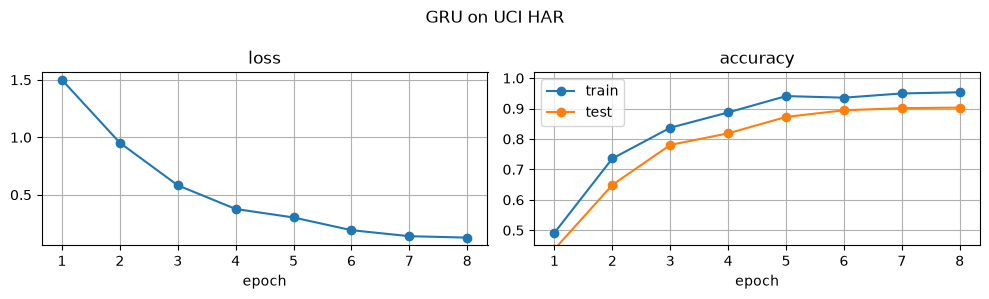

In [22]:
set_seed(42)
har_model = BuiltinRNNClassifier(kind="gru", input_dim=9, hidden_dim=64, num_classes=6)
har_history = train_classifier(
    har_model,
    har_train_loader,
    har_test_loader,
    epochs=8,
    lr=1e-3,
    clip=1.0,
)
plot_history(har_history, "GRU on UCI HAR")

### 推論してみる

学習したモデルにテストデータを1件入力し、予測ラベルと正解ラベルを比較します。`sample_index` を変えると別のサンプルで推論できます。

In [23]:
def predict_har(model, x_one):
    model.eval()
    with torch.no_grad():
        logits = model(x_one.unsqueeze(0).to(device))
        prob = torch.softmax(logits, dim=-1)[0].cpu()
        pred_id = int(prob.argmax())
    return pred_id, prob


sample_index = 0
pred_id, prob = predict_har(har_model, x_test_har[sample_index])
true_id = int(y_test_har[sample_index])

print("true:", ACTIVITY_NAMES[true_id])
print("pred:", ACTIVITY_NAMES[pred_id])
print("probabilities:")
for name, p in zip(ACTIVITY_NAMES, prob):
    print(f"  {name:20s}: {float(p):.3f}")

true: STANDING
pred: STANDING
probabilities:
  WALKING             : 0.012
  WALKING_UPSTAIRS    : 0.000
  WALKING_DOWNSTAIRS  : 0.002
  SITTING             : 0.029
  STANDING            : 0.956
  LAYING              : 0.000


### 混同行列で間違い方を見る

accuracyだけでは、どの行動を間違えやすいかが分かりません。混同行列を見ると、たとえば `SITTING` と `STANDING` のように姿勢が近いクラスを混同しているか確認できます。

tensor([[451,   9,  36,   0,   0,   0],
        [  9, 455,   7,   0,   0,   0],
        [  2,   6, 412,   0,   0,   0],
        [ 15,   5,   4, 372,  95,   0],
        [  2,   0,   0,  69, 461,   0],
        [  0,  27,   0,   0,   0, 510]])


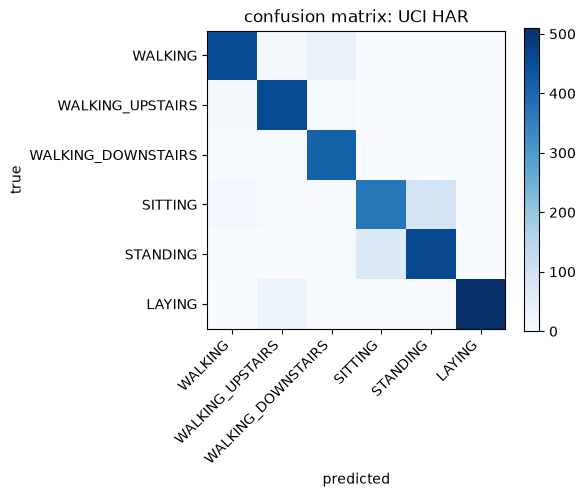

In [24]:
def confusion_matrix_torch(model, loader, num_classes):
    cm = torch.zeros(num_classes, num_classes, dtype=torch.long)
    model.eval()
    with torch.no_grad():
        for xb, yb in loader:
            pred = model(xb.to(device)).argmax(dim=-1).cpu()
            for true, guessed in zip(yb, pred):
                cm[int(true), int(guessed)] += 1
    return cm


cm = confusion_matrix_torch(har_model, har_test_loader, num_classes=6)
print(cm)

plt.figure(figsize=(6, 5))
plt.imshow(cm.numpy(), cmap="Blues")
plt.xticks(range(6), ACTIVITY_NAMES, rotation=45, ha="right")
plt.yticks(range(6), ACTIVITY_NAMES)
plt.xlabel("predicted")
plt.ylabel("true")
plt.colorbar()
plt.title("confusion matrix: UCI HAR")
plt.tight_layout()
plt.show()